<a href="https://colab.research.google.com/github/gasortiz-hash/PichIA/blob/main/PichIA_Traning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📁 Montando Google Drive...
Mounted at /content/drive
✅ Todos los resultados se guardarán en: /content/drive/MyDrive/PichiaCLM_Proyecto

🚀 MODELO AVANZADO DE OPTIMIZACIÓN DE CODONES (XGBoost)
📥 Clonando repositorio por primera vez en Drive...
Cloning into '/content/drive/MyDrive/PichiaCLM_Proyecto/PichiaCLM'...
remote: Enumerating objects: 451, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 451 (delta 24), reused 16 (delta 16), pack-reused 422 (from 1)
Receiving objects: 100% (451/451), 150.65 MiB | 16.22 MiB/s, done.
Resolving deltas: 100% (95/95), done.
Updating files: 100% (272/272), done.

🔍 Buscando archivos CSV...
   ✅ Encontrado: CBS7435.csv
   ✅ Encontrado: GS115_ext.csv
   ✅ Encontrado: Kpastoris_WT.csv
   ✅ Encontrado: Kphaffi_GS115_int.csv
   ✅ Encontrado: Kphaffi_WT.csv

💾 Base de datos combinada guardada en Drive: /content/drive/MyDrive/PichiaCLM_Proyecto/base_datos_combinada.csv
📊 Total de secuencias combi

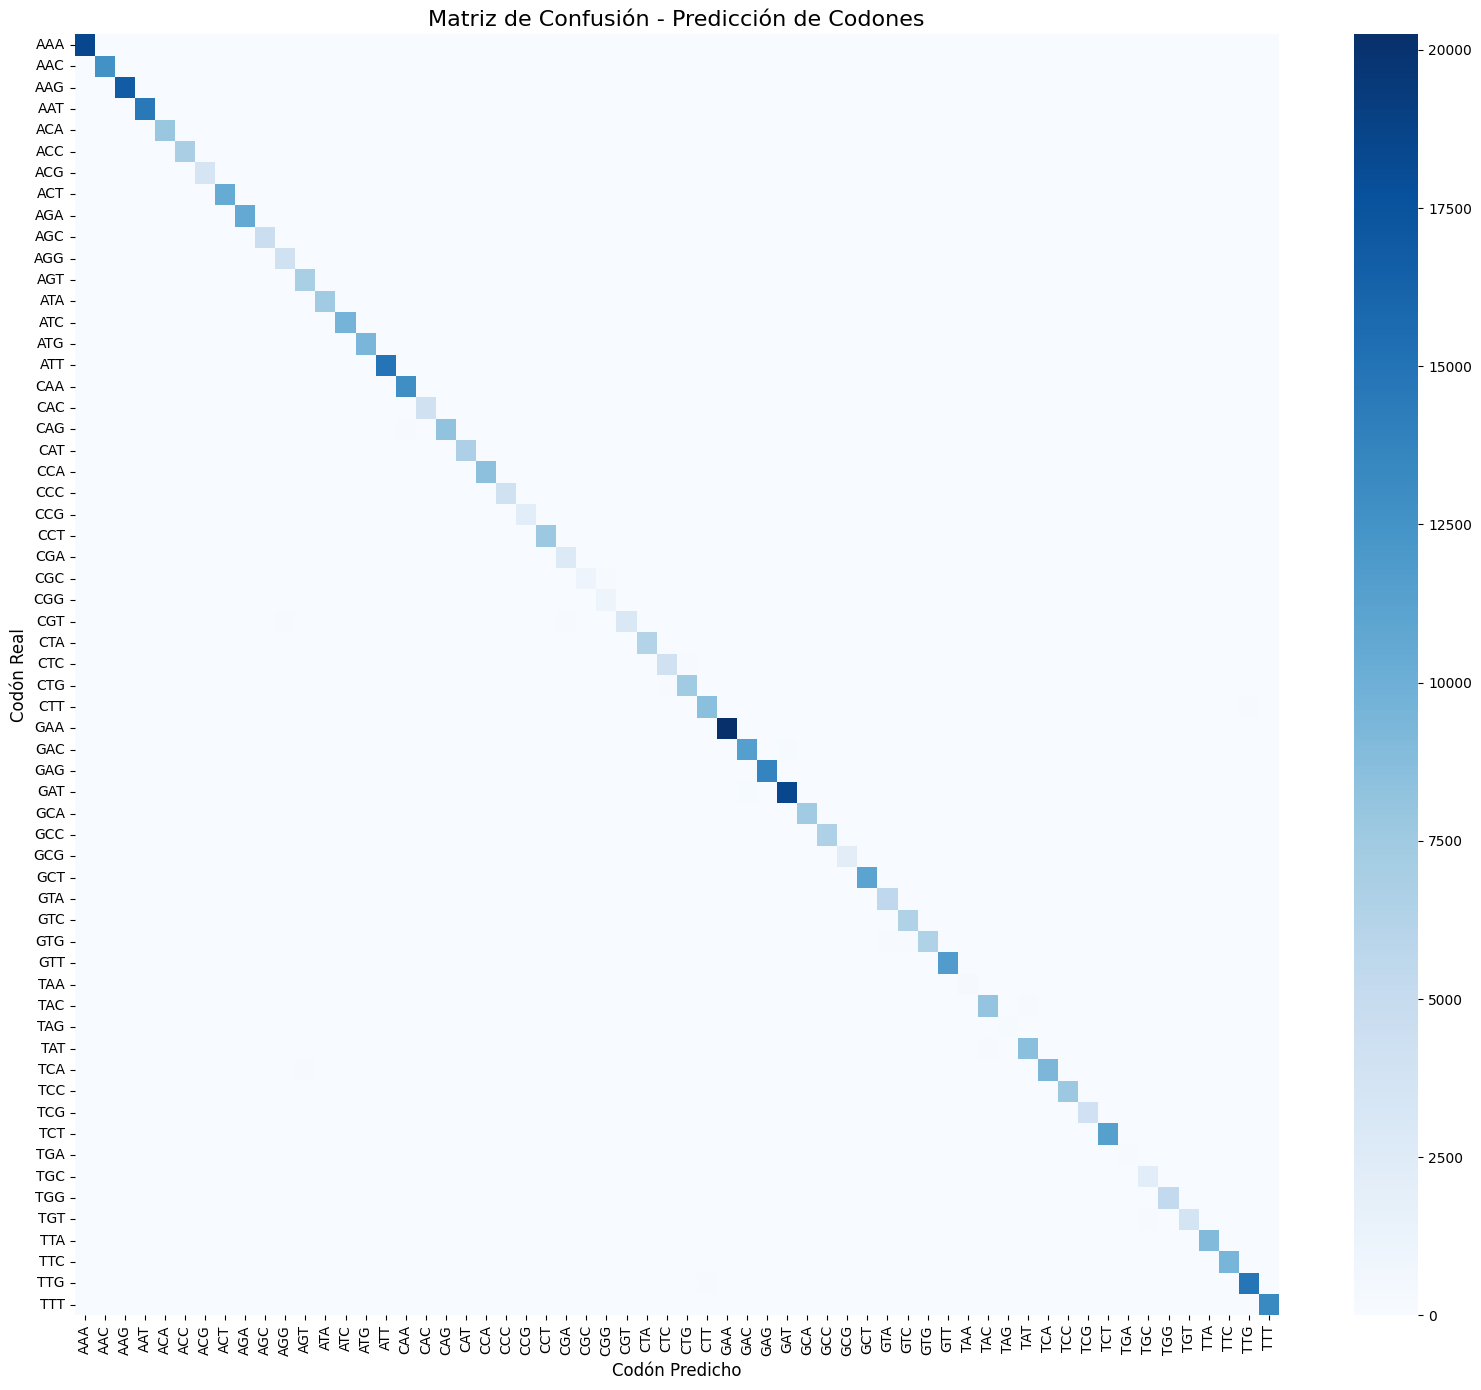

   📈 Matriz de confusión guardada en: /content/drive/MyDrive/PichiaCLM_Proyecto/matriz_confusion.png


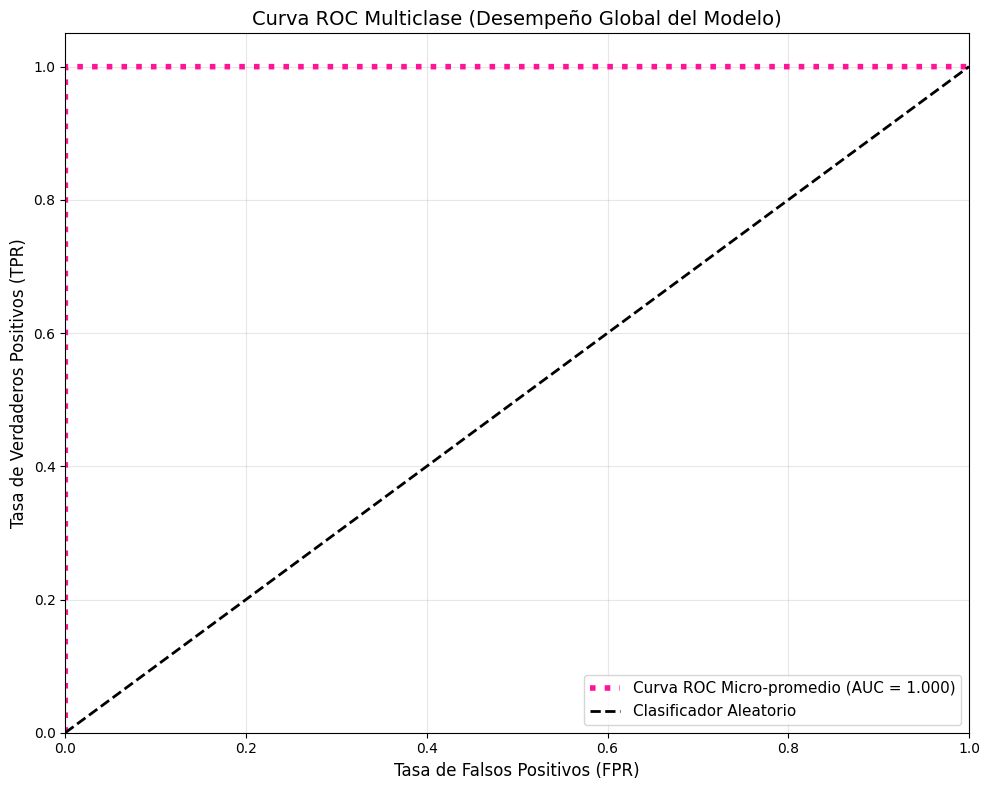

   📈 Curva ROC guardada en: /content/drive/MyDrive/PichiaCLM_Proyecto/curva_roc.png

✅ ¡PROCESO COMPLETADO EXITOMENTE Y ARCHIVOS SALVADOS EN DRIVE!


In [ ]:
# ================================================================
# XGBOOST TRAINING MODEL
# ================================================================

import os
import glob
import pickle
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import xgboost as xgb

warnings.filterwarnings('ignore')

# ========== 0. MOUNT GOOGLE DRIVE AND CONFIGURE DIRECTORIES ==========
print("📁 Mounting Google Drive...")
drive.mount('/content/drive')

# Define the folder in your Drive where everything will be saved
DRIVE_DIR = '/content/drive/MyDrive/PichIA'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"✅ All results will be saved in: {DRIVE_DIR}\n")

# ========== PARAMETER CONFIGURATION ==========
SAMPLE_FRACTION = 0.2       # 0.5 or 1.0 (more data -> better precision)
WINDOW_SIZE = 5             # Contextual window size
USE_GC = True               # Local GC content
USE_CODON_PAIR = True       # Codon pair frequency
GRID_SEARCH = False         # True to optimize hyperparameters
RAPID_TEST = False          # True for quick tests (10,000 examples)

print("=" * 70)
print("🚀 ADVANCED CODON OPTIMIZATION MODEL (XGBoost)")
print("=" * 70)

# ========== 1. DATA LOADING AND PERSISTENCE TO DRIVE ==========
REPO_DIR = os.path.join(DRIVE_DIR, "PichiaCLM")

# If the repository does not exist in Drive, clone it directly there to avoid losing it
if not os.path.exists(REPO_DIR):
    print("📥 Cloning repository for the first time in Drive...")
    !git clone https://github.com/NHarini-1995/PichiaCLM.git {REPO_DIR}
else:
    print("✅ Repository previously found in Drive.")

print("\n🔍 Searching for CSV files...")
csv_patterns = [
    'CBS7435.csv', 'GS115_ext.csv', 'Kpastoris_WT.csv',
    'Kphaffi_GS115_int.csv', 'Kphaffi_WT.csv'
]

found_files = []
for pattern in csv_patterns:
    matches = glob.glob(f'{REPO_DIR}/**/{pattern}', recursive=True)
    if matches:
        found_files.append(matches[0])
        print(f"   ✅ Found: {os.path.basename(matches[0])}")

if not found_files:
    raise FileNotFoundError("No CSV files found.")

dataframes = []
for file in found_files:
    df = pd.read_csv(file)
    aa_col = next((c for c in df.columns if c.lower() in ['aa', 'aa_seq', 'aminoacid']), None)
    cds_col = next((c for c in df.columns if c.lower() in ['cds', 'cds_seq']), None)
    if aa_col and cds_col:
        df.rename(columns={aa_col: 'AA', cds_col: 'CDS'}, inplace=True)
        df = df.dropna(subset=['AA', 'CDS'])
        dataframes.append(df)

all_data = pd.concat(dataframes, ignore_index=True)

# Save the complete combined database to Drive as backup
combined_csv_path = os.path.join(DRIVE_DIR, 'base_datos_combinada.csv')
all_data.to_csv(combined_csv_path, index=False)
print(f"\n💾 Combined database saved to Drive: {combined_csv_path}")
print(f"📊 Total combined sequences: {len(all_data)}")

# ========== 2. AMINO ACID MAPPING ==========
all_aa = 'ACDEFGHIKLMNPQRSTVWY*'
aa_to_idx = {aa: i for i, aa in enumerate(all_aa)}

# ========== 3. PROCESSING FUNCTIONS ==========
def create_examples(aa_seq, cds_seq, window=WINDOW_SIZE):
    examples = []
    for i in range(len(aa_seq)):
        context = []
        for j in range(i-window, i+window+1):
            if j < 0 or j >= len(aa_seq):
                context.append('*')
            else:
                context.append(aa_seq[j])

        pos = i / len(aa_seq) if len(aa_seq) > 1 else 0.5
        codon = cds_seq[i*3:(i+1)*3]

        gc_local = 0.0
        if USE_GC:
            start = max(0, i-3)
            end = min(len(aa_seq), i+4)
            local_cds = cds_seq[start*3:end*3]
            if len(local_cds) > 0:
                gc_local = (local_cds.count('G') + local_cds.count('C')) / len(local_cds)

        if USE_CODON_PAIR:
            codon_pair = (codon, cds_seq[(i+1)*3:(i+2)*3] if i+1 < len(aa_seq) else '---')
            examples.append({
                'context': ''.join(context),
                'pos': pos,
                'codon': codon,
                'gc_local': gc_local,
                'codon_pair': codon_pair
            })
        else:
            examples.append({
                'context': ''.join(context),
                'pos': pos,
                'codon': codon,
                'gc_local': gc_local
            })
    return examples

# ========== 4. EXAMPLE GENERATION ==========
print(f"\n🔨 Generating examples with window={WINDOW_SIZE}...")
start_time = time.time()
all_examples = []
for idx, row in all_data.sample(frac=SAMPLE_FRACTION, random_state=42).iterrows():
    aa_seq = row['AA']
    cds_seq = row['CDS']
    if len(aa_seq) * 3 != len(cds_seq):
        continue
    examples = create_examples(aa_seq, cds_seq, window=WINDOW_SIZE)
    all_examples.extend(examples)

# Filter non-standard codons
valid_codons = {
    'GCT', 'GCC', 'GCA', 'GCG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG',
    'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'GAT', 'GAC', 'GAA', 'GAG',
    'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'TGT', 'TGC',
    'TTC', 'TTT', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG',
    'ATG', 'ATT', 'ATC', 'ATA', 'CCT', 'CCC', 'CCA', 'CCG',
    'ACT', 'ACC', 'ACA', 'ACG', 'GTT', 'GTC', 'GTA', 'GTG',
    'TGG', 'TAT', 'TAC', 'TAA', 'TAG', 'TGA'
}
all_examples = [ex for ex in all_examples if ex['codon'] in valid_codons]

if RAPID_TEST and len(all_examples) > 10000:
    import random
    all_examples = random.sample(all_examples, 10000)

# ========== 5. FEATURE VECTORIZATION ==========
codon_pair_freq = {}
if USE_CODON_PAIR:
    pairs = [ex['codon_pair'] for ex in all_examples if ex['codon_pair'][1] != '---']
    pair_counts = {}
    for p in pairs:
        pair_counts[p] = pair_counts.get(p, 0) + 1
    total_pairs = sum(pair_counts.values())
    codon_pair_freq = {p: count/total_pairs for p, count in pair_counts.items()}

def encode_context(context_str):
    return [aa_to_idx.get(aa, 20) for aa in context_str]

X, y = [], []
for ex in all_examples:
    context_encoded = encode_context(ex['context'])
    features = context_encoded + [ex['pos']]
    if USE_GC:
        features.append(ex['gc_local'])
    if USE_CODON_PAIR:
        pair_score = codon_pair_freq.get(ex['codon_pair'], 0.0)
        features.append(pair_score)
    X.append(features)
    y.append(ex['codon'])

X = np.array(X)
y = np.array(y)

unique_codons = sorted(set(y))
codon_to_int = {c: i for i, c in enumerate(unique_codons)}
int_to_codon = {i: c for c, i in codon_to_int.items()}
y_encoded = np.array([codon_to_int[c] for c in y])

# ========== 6. SPLITTING AND TRAINING ==========
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

base_params = {
    'n_estimators': 200,
    'max_depth': 14,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'tree_method': 'hist',
    'eval_metric': 'mlogloss',
    'verbosity': 0,
    'num_class': len(unique_codons)
}

print("\n🧠 Training XGBoost...")
model = xgb.XGBClassifier(**base_params)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ========== 7. GENERATING AND SAVING PERFORMANCE PLOTS ==========
print("\n📊 Generating and saving metric plots...")

# --- 1. CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    xticklabels=unique_codons,
    yticklabels=unique_codons,
    cmap='Blues',
    fmt='d',
    cbar=True
)
plt.title('Confusion Matrix - Codon Prediction', fontsize=16)
plt.xlabel('Predicted Codon', fontsize=12)
plt.ylabel('Actual Codon', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(DRIVE_DIR, 'matriz_confusion.png')
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"   📈 Confusion matrix saved to: {cm_path}")

# --- 2. ROC CURVES (Micro-average for multi-class) ---
y_test_bin = label_binarize(y_test, classes=list(range(len(unique_codons))))

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(10, 8))
plt.plot(
    fpr_micro, tpr_micro,
    label=f'Micro-average ROC Curve (AUC = {roc_auc_micro:.3f})',
    color='deeppink', linestyle=':', linewidth=4
)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Multi-class ROC Curve (Global Model Performance)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(DRIVE_DIR, 'curva_roc.png')
plt.savefig(roc_path, dpi=300)
plt.show()
print(f"   📈 ROC Curve saved to: {roc_path}")

# ========== 8. SAVING MODEL AND MAPPINGS TO DRIVE ==========
model_path = os.path.join(DRIVE_DIR, 'modelo_avanzado.pkl')
c2i_path = os.path.join(DRIVE_DIR, 'codon_to_int_avanzado.pkl')
i2c_path = os.path.join(DRIVE_DIR, 'int_to_codon_avanzado.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
with open(c2i_path, 'wb') as f:
    pickle.dump(codon_to_int, f)
with open(i2c_path, 'wb') as f:
    pickle.dump(int_to_codon, f)

print("\n" + "=" * 70)
print("✅ PROCESS COMPLETED SUCCESSFULLY AND FILES SAVED TO DRIVE!")
print("=" * 70)

## Methodology: XGBoost Codon Optimization Model

This project implements an advanced machine learning model using XGBoost to predict optimal codons for a given amino acid, considering various biological contexts. The methodology encompasses data acquisition, rigorous feature engineering, model training, and comprehensive evaluation, culminating in a robust tool for codon optimization.

### 1. Data Acquisition and Preparation

*   **Source Data:** The model leverages data from multiple `Pichia pastoris` strains (e.g., CBS7435, GS115_ext) in CSV format, sourced from a dedicated GitHub repository (`NHarini-1995/PichiaCLM.git`). This repository is cloned directly into Google Drive for persistent storage.
*   **Data Consolidation:** Individual CSV files containing amino acid (AA) and coding sequence (CDS) pairs are loaded, normalized for column names, cleaned of missing values, and then concatenated into a single master dataset. This combined dataset is saved for reproducibility.
*   **Amino Acid Mapping:** A numerical mapping is created for all 20 standard amino acids plus a wildcard character (`*`) to facilitate numerical representation of amino acid contexts.

### 2. Feature Engineering

For each amino acid in a sequence, the following features are extracted to capture relevant biological information:

*   **Contextual Amino Acids:** A sliding window (`WINDOW_SIZE` = 5) of preceding and succeeding amino acids is extracted. Positions outside the sequence boundaries are filled with a wildcard (`*`).
*   **Positional Information:** The relative position of the amino acid within its sequence (normalized between 0 and 1) is included as a feature.
*   **Local GC Content (Optional):** The GC content of a small nucleotide window around the current codon in the CDS is calculated, providing insights into local genomic composition.
*   **Codon Pair Frequency (Optional):** The frequency of the current codon appearing with its subsequent codon within the entire dataset is computed. This feature helps capture common codon-codon interactions.

These features, along with the target codon, form the training examples. Only valid codons (as per a predefined set) are considered.

### 3. Model Training

*   **Model Architecture:** An **XGBoost Classifier** (`xgboost.XGBClassifier`) is employed due to its efficiency and strong performance in classification tasks.
*   **Data Splitting:** The engineered features (`X`) and encoded target codons (`y_encoded`) are split into training (80%) and testing (20%) sets using `sklearn.model_selection.train_test_split` to ensure unbiased evaluation.
*   **Hyperparameters:** The XGBoost model is configured with a predefined set of hyperparameters (e.g., `n_estimators=200`, `max_depth=14`, `learning_rate=0.1`) suitable for multi-class classification, with the number of classes set to the total unique codons.
*   **Training Process:** The model is trained on the `X_train` and `y_train` datasets.

### 4. Model Evaluation

The trained model's performance is rigorously assessed using standard classification metrics:

*   **Accuracy Score:** The overall accuracy of the model on the unseen test set (`X_test`, `y_test`) is calculated.
*   **Confusion Matrix:** A detailed confusion matrix is generated and visualized as a heatmap. This matrix illustrates the number of correct and incorrect predictions for each codon, highlighting specific misclassifications.
*   **Micro-average ROC Curve:** For multi-class classification, a micro-average Receiver Operating Characteristic (ROC) curve is plotted, and its Area Under the Curve (AUC) is calculated. This provides an aggregate measure of the model's ability to distinguish between all codon classes.

All evaluation plots (confusion matrix, ROC curve) are saved as PNG files in the designated Google Drive directory.

### 5. Model Persistence

Upon successful training and evaluation, the following assets are serialized using Python's `pickle` module and saved to Google Drive for future use without the need for retraining:

*   The trained XGBoost model (`modelo_avanzado.pkl`).
*   The codon-to-integer mapping dictionary (`codon_to_int_avanzado.pkl`).
*   The integer-to-codon mapping dictionary (`int_to_codon_avanzado.pkl`).